# First-Order Perturbation of CXS Intensity Patterns

This notebook demonstrates **first-order distribution perturbation** applied directly to
coherent X-ray scattering (CXS) intensity patterns produced by the Kuramoto oscillator
system from the dynamiCXS framework.

**First-order perturbation** means the perturbation is applied to the model *input* — the
2-D intensity pattern — rather than to the physical process that generated it. Four
perturbations are demonstrated:

| Perturber | Physical analogue | `dist_pert` class |
|-----------|------------------|-------------------|
| Gaussian noise | Electronic detector read-noise | `GaussianNoisePerturber` |
| Salt-and-pepper | Stuck / hot pixels | `SaltPepperPerturber` |
| Shot noise (Poisson) | Photon counting statistics | `ImageCorruptionPerturber(shot_noise)` |
| Gaussian blur | Finite detector PSF | `ImageCorruptionPerturber(gaussian_blur)` |

All perturbers are applied to uint8 images. The CXS intensities are log-scaled and
normalised to [0, 255] before perturbation, which is a typical pre-processing step
when feeding diffraction data to downstream models.

## Setup

In [1]:
%matplotlib inline
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

# dynamiCXS lives in the submodule
sys.path.insert(0, 'dynamiCXS/dynamicxs')

from ode import Kuramoto
from cxs import CXSGrid

# dist_pert is installed from the repo root (pip install -e .)
from dist_pert.image import GaussianNoisePerturber, SaltPepperPerturber, ImageCorruptionPerturber

/Users/echagnon/vscode-projects/distribution_perturbation/examples/coherent_scattering_example/coherent_scattering_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/echagnon/vscode-projects/distribution_perturbation/examples/coherent_scattering_example/coherent_scattering_env/lib/python3.12/site-packages/imagecorruptions/corruptions.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## Simulate Kuramoto oscillators and compute CXS patterns

We use the same parameters as `kuramoto.ipynb`: an 80×80 grid of coupled phase
oscillators. The CXS forward model maps a phase-field snapshot to a reciprocal-space
intensity pattern via `fftshift(|FFT2(ifftshift(probe * field))|²)`.

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
default_type = torch.float64
torch.set_default_dtype(default_type)

# --- Simulate Kuramoto trajectory ---
args = {'N': 80, 'L': 2., 'v': 0, 'K': 20., 's': 1.5}
M = 10  # number of independent realisations

kuramoto = Kuramoto(args, method='dopri5', default_type=default_type)
kuramoto.init_state(M)
kuramoto.to(device)

t = torch.linspace(0, 30, 61)
kuramoto.solve(t, device=device)
kuramoto.trim(t0=10)

print(f'Trajectory shape (T, M, 1, N²): {kuramoto.y.shape}')

Elapsed time: 10.05 s
Trajectory shape (T, M, 1, N²): torch.Size([51, 10, 1, 6400])


In [3]:
# --- CXS forward model ---
cxs = CXSGrid(
    kuramoto.N, n=42, L=kuramoto.L,
    dq=0.5, f_probe=0.25, f_mask=0.06, f='phase'
).to(device)

# Compute intensity patterns for all time steps and realisations
# Output shape: (T, M, n*n) — flat; reshape to (n, n) for display
with torch.no_grad():
    Y = cxs(kuramoto.y)

# Select a single snapshot: last time step, first realisation, reshaped to (n, n)
Y_single = Y[-1, 0].reshape(cxs.n, cxs.n).cpu().numpy()
print(f'Pattern shape: {Y_single.shape}, range: [{Y_single.min():.2e}, {Y_single.max():.2e}]')

Pattern shape: (84, 84), range: [0.00e+00, 1.49e+07]


## Preprocess: log-scale and normalise to uint8

`dist_pert` image perturbers expect uint8 arrays (H×W×C). CXS patterns are 2-D
and span many orders of magnitude, so we log-scale and normalise to [0, 255].
The channel dimension is added via `[:, :, np.newaxis]`.

In [4]:
def to_uint8(pattern: np.ndarray) -> np.ndarray:
    """Log-scale a CXS intensity pattern and map to uint8 H×W×3.

    PIL-based perturbers require at least 3 channels; the same intensity is
    tiled across all three so the pattern is treated as a grayscale RGB image.
    """
    log_p = np.log10(pattern + 1.0)
    normed = (log_p - log_p.min()) / (log_p.max() - log_p.min() + 1e-12)
    gray = (normed * 255).astype(np.uint8)
    return np.stack([gray, gray, gray], axis=-1)  # (H, W, 3)


def from_uint8(image: np.ndarray) -> np.ndarray:
    """Take first channel; return float array in [0, 1]."""
    return image[:, :, 0].astype(np.float32) / 255.0


clean_uint8 = to_uint8(Y_single)  # (n, n, 3) uint8
print(f'uint8 image shape: {clean_uint8.shape}, dtype: {clean_uint8.dtype}')

uint8 image shape: (84, 84, 3), dtype: uint8


## Apply first-order perturbations

In [5]:
# Instantiate perturbers
gaussian_noise = GaussianNoisePerturber(sigma=15)
salt_pepper    = SaltPepperPerturber(amount=0.05)
shot_noise     = ImageCorruptionPerturber(corruption='shot_noise', severity=3)
blur           = ImageCorruptionPerturber(corruption='gaussian_blur', severity=2)

# Apply each perturber to the same clean image
perturbers = {
    'Gaussian noise\n(σ=15)':    gaussian_noise,
    'Salt & pepper\n(amount=5%)': salt_pepper,
    'Shot noise\n(severity=3)':  shot_noise,
    'Gaussian blur\n(severity=2)': blur,
}

results: dict[str, np.ndarray] = {}
for name, perturber in perturbers.items():
    perturbed = perturber([clean_uint8])[0]  # list in, list out
    results[name] = perturbed

## Visualise: clean vs. perturbed patterns

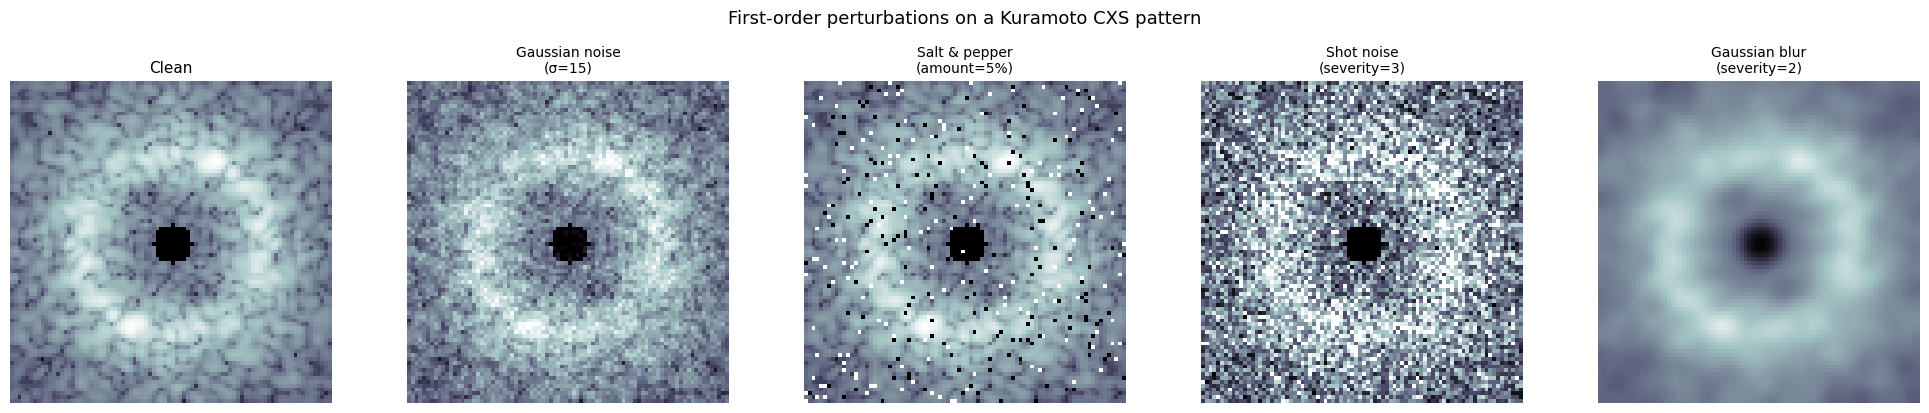

In [6]:
ncols = len(results) + 1  # clean + one per perturber
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

imshow_kw = dict(cmap='bone', vmin=0, vmax=255, interpolation='nearest')

axes[0].imshow(clean_uint8[:, :, 0], **imshow_kw)
axes[0].set_title('Clean', fontsize=11)
axes[0].axis('off')

for ax, (name, perturbed) in zip(axes[1:], results.items()):
    ax.imshow(perturbed[:, :, 0], **imshow_kw)
    ax.set_title(name, fontsize=10)
    ax.axis('off')

fig.suptitle('First-order perturbations on a Kuramoto CXS pattern', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## Quantify perturbation magnitude

Mean absolute error (MAE) and relative MAE between the clean and each perturbed
pattern, computed in [0, 1] float space.

In [7]:
clean_float = from_uint8(clean_uint8)  # (n, n) in [0,1]

print(f'{'Perturber':<32}  {'MAE':>8}  {'Rel. MAE':>10}')
print('-' * 54)
for name, perturbed in results.items():
    p_float = from_uint8(perturbed)
    mae = np.abs(p_float - clean_float).mean()
    rel_mae = mae / (clean_float.mean() + 1e-12)
    label = name.replace('\n', ' ')
    print(f'{label:<32}  {mae:>8.4f}  {rel_mae:>10.4f}')

Perturber                              MAE    Rel. MAE
------------------------------------------------------
Gaussian noise (σ=15)               0.0460      0.0773
Salt & pepper (amount=5%)           0.0255      0.0429
Shot noise (severity=3)             0.1646      0.2769
Gaussian blur (severity=2)          0.0486      0.0817


## Batch mode: perturb multiple snapshots

`dist_pert` perturbers accept a list of arrays and return a list. Here we perturb
all M realisations at the last time step in a single call.

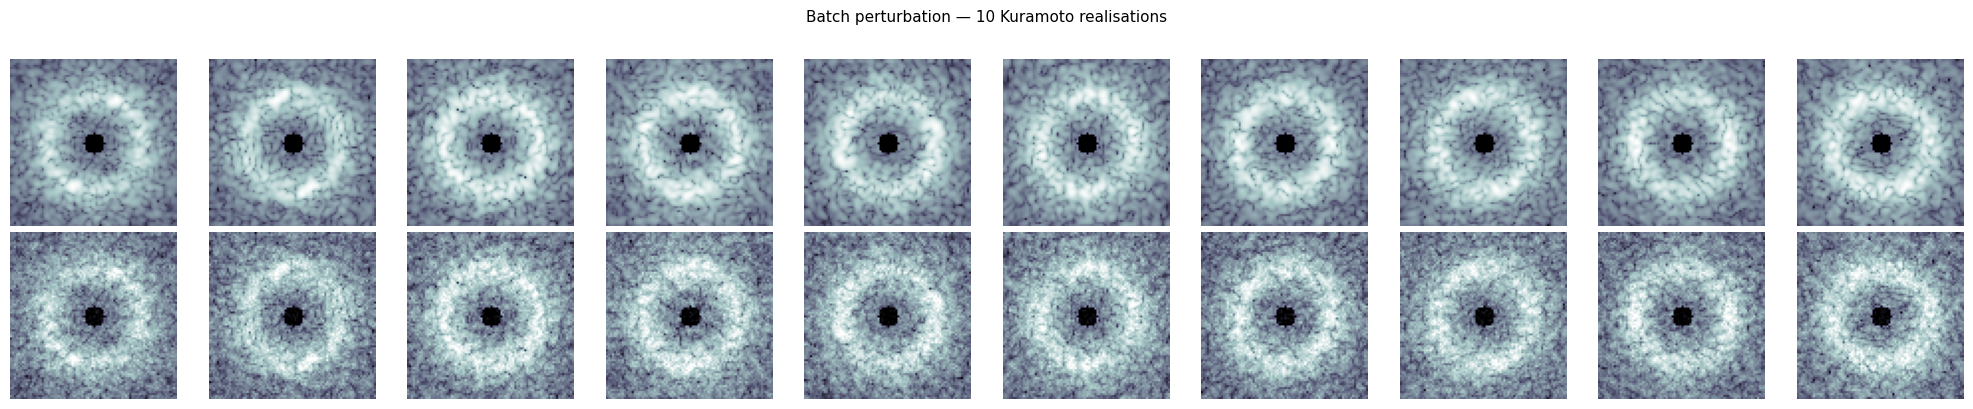

Perturbed 10 patterns.


In [8]:
# Build a batch: last time step, all M realisations
batch_clean = [
    to_uint8(Y[-1, m].reshape(cxs.n, cxs.n).cpu().numpy())
    for m in range(M)
]

batch_noisy = gaussian_noise(batch_clean)  # list of M perturbed uint8 images

fig, axes = plt.subplots(2, M, figsize=(2 * M, 4))
for m in range(M):
    axes[0, m].imshow(batch_clean[m][:, :, 0], cmap='bone', vmin=0, vmax=255)
    axes[0, m].axis('off')
    axes[1, m].imshow(batch_noisy[m][:, :, 0], cmap='bone', vmin=0, vmax=255)
    axes[1, m].axis('off')

axes[0, 0].set_ylabel('Clean', fontsize=10)
axes[1, 0].set_ylabel('Gaussian noise', fontsize=10)
fig.suptitle(f'Batch perturbation — {M} Kuramoto realisations', fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

print(f'Perturbed {len(batch_noisy)} patterns.')

## Severity sweep

Sweep `shot_noise` from severity 1 to 5 to see how signal fidelity degrades.

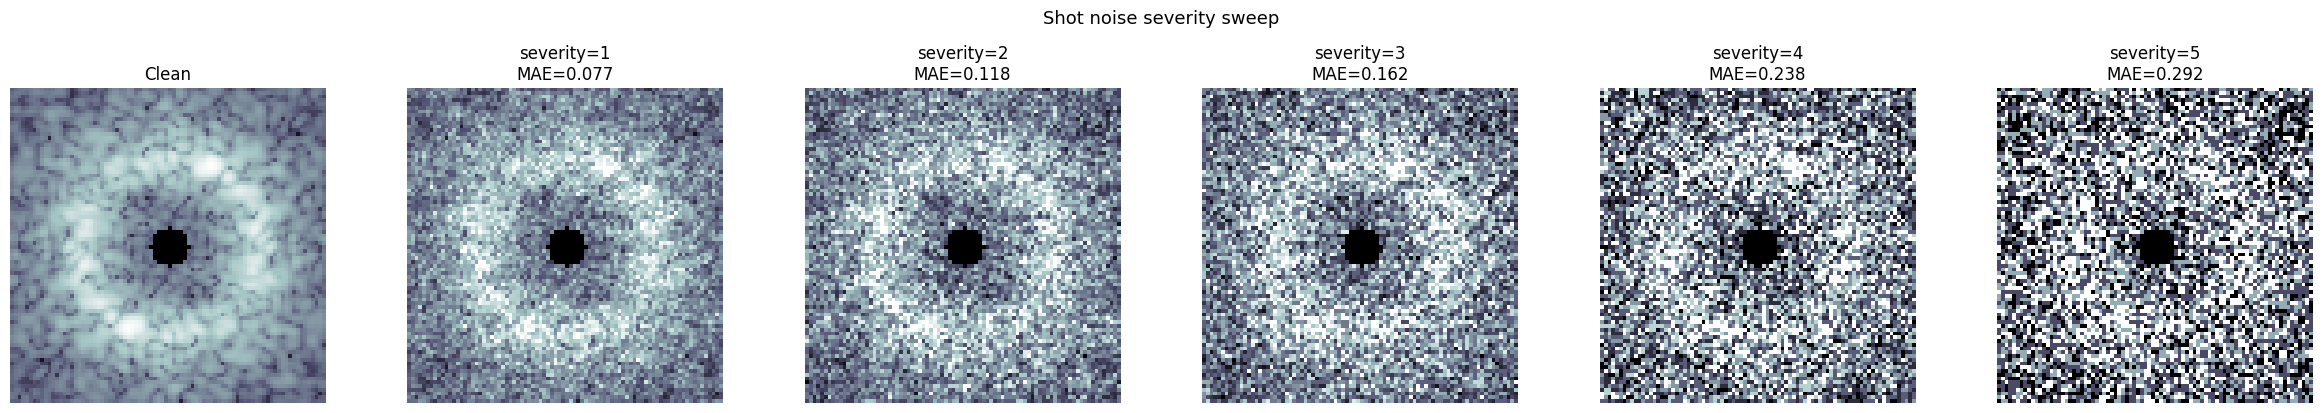

In [9]:
severities = [1, 2, 3, 4, 5]
fig, axes = plt.subplots(1, len(severities) + 1, figsize=(4 * (len(severities) + 1), 4))

axes[0].imshow(clean_uint8[:, :, 0], cmap='bone', vmin=0, vmax=255)
axes[0].set_title('Clean')
axes[0].axis('off')

for ax, sev in zip(axes[1:], severities):
    perturber = ImageCorruptionPerturber(corruption='shot_noise', severity=sev)
    perturbed = perturber([clean_uint8])[0]
    mae = np.abs(from_uint8(perturbed) - clean_float).mean()
    ax.imshow(perturbed[:, :, 0], cmap='bone', vmin=0, vmax=255)
    ax.set_title(f'severity={sev}\nMAE={mae:.3f}')
    ax.axis('off')

fig.suptitle('Shot noise severity sweep', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()